In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv


### 1. Carregamento Automático do Dataset e Tratamento de Encoding

Este bloco de código realiza a busca dinâmica e o carregamento do dataset no ambiente do Kaggle. A lógica está dividida em duas etapas principais:

1. **Mapeamento do Diretório:** Varre a pasta `/kaggle/input` para localizar automaticamente o arquivo de dados (`.tsv`, `.csv` ou `.xlsx`), evitando caminhos fixos (*hardcoded*).
2. **Carregamento Resiliente:** Tenta ler o arquivo como um arquivo separado por tabulações (`.tsv`) utilizando codificação `utf-8`. Caso encontre caracteres especiais incompatíveis, aciona um mecanismo de contingência (*try-except*) para tentar a leitura em `iso-8859-1` (Latin1), garantindo a integridade da acentuação em português.
   

In [2]:
import os
import pandas as pd
import numpy as np

# 1. Identificar o caminho do arquivo automaticamente no Kaggle
caminho_arquivo = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        # Procurando arquivos comuns de dados (.csv, .tsv, .xlsx)
        if filename.endswith(('.csv', '.tsv', '.xlsx', '.txt')):
            caminho_arquivo = os.path.join(dirname, filename)
            print(f"Dataset encontrado: {caminho_arquivo}")

# Caso você use o kagglehub para baixar dinamicamente, descomente as linhas abaixo:
# path = kagglehub.dataset_download('georgekurokijr/dl-2024')
# caminho_arquivo = os.path.join(path, os.listdir(path)[0])

if caminho_arquivo is None:
    raise FileNotFoundError("Nenhum arquivo de dados foi encontrado no diretório /kaggle/input. Certifique-se de adicionar o Dataset ao seu Notebook à direita.")

# 2. Carregamento dos dados tratando o encoding (essencial para acentuação em português)
try:
    # Tentativa 1: Padrão UTF-8 (separador tabulação, comum em arquivos científicos .tsv)
    df_raw = pd.read_csv(caminho_arquivo, sep='\t', encoding='utf-8')
except UnicodeDecodeError:
    # Tentativa 2: ISO-8859-1 / Latin1 se houver caracteres incompatíveis
    df_raw = pd.read_csv(caminho_arquivo, sep='\t', encoding='iso-8859-1')
except Exception as e:
    # Tentativa 3: Se for CSV separado por vírgula convencional
    df_raw = pd.read_csv(caminho_arquivo, encoding='utf-8')

print(f"\nDados carregados com sucesso! Formato original: {df_raw.shape}")
print("Colunas encontradas:", list(df_raw.columns))

Dataset encontrado: /kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv

Dados carregados com sucesso! Formato original: (2725, 2)
Colunas encontradas: ['Título_Público', 'Descricao_pública']


### 2. Filtragem de Ruídos e Consolidação Textual

Nesta etapa, o dataset passa por um processo de higienização automatizada para eliminar registros inválidos e preparar os textos para os modelos de Deep Learning:

1. **Remoção de Nulos:** Elimina linhas com dados ausentes nas colunas essenciais (`Título_Público` e `Descricao_pública`).
2. **Filtro por Expressões Regulares (Regex):** Identifica e remove projetos que contenham marcações textuais administrativas ou sigilosas (como *"confidencial"*, *"projeto cancelado"*, *"a definir"*), aplicando a flag `re.IGNORECASE` para garantir a compatibilidade com o interpretador Python 3.12.
3. **Consolidação do Corpus:** Cria a coluna `texto_completo` realizando a junção convencional do título e da descrição do projeto, servindo como o dado textual de entrada unificado para as etapas seguintes.

In [3]:
import re

# 1. Criar uma cópia para trabalhar os dados limpos
df_clean = df_raw.dropna(subset=['Título_Público', 'Descricao_pública']).copy()

# Converter para string e remover espaços em branco nas extremidades
df_clean['Título_Público'] = df_clean['Título_Público'].astype(str).str.strip()
df_clean['Descricao_pública'] = df_clean['Descricao_pública'].astype(str).str.strip()

# 2. Definir os padrões de texto SEM as flags inline (?i)
padroes_ruido = [
    r'confidencial', 
    r'^a definir$', 
    r'projeto cancelado',
    r'teste de sistema',
    r'^sem descri[cç][aã]o$'
]

# Unir os padrões em uma regex limpa
regex_ruido = '|'.join(padroes_ruido)

# 3. Filtrar usando o argumento flags=re.IGNORECASE do próprio Pandas
# Isso aplica o "case insensitive" globalmente e do jeito correto para o Python 3.12
linhas_validas = ~(
    df_clean['Título_Público'].str.contains(regex_ruido, na=False, flags=re.IGNORECASE) | 
    df_clean['Descricao_pública'].str.contains(regex_ruido, na=False, flags=re.IGNORECASE)
)

df_clean = df_clean[linhas_validas].reset_index(drop=True)

# 4. Junção convencional de Título e Descrição (mantendo o padrão original do seu grupo)
df_clean['texto_completo'] = df_clean['Título_Público'] + " . " + df_clean['Descricao_pública']

print(f"Dados após a filtragem de ruídos: {df_clean.shape}")
print(f"Total de registros removidos: {df_raw.shape[0] - df_clean.shape[0]}")
print("\nExemplo do primeiro texto completo:")
print(df_clean['texto_completo'].iloc[0][:300] + "...")

Dados após a filtragem de ruídos: (2705, 3)
Total de registros removidos: 20

Exemplo do primeiro texto completo:
Açúcar de frutas e aplicação em bolos como substituto da sacarose . O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, produtos e serviços de forma sustentável a partir de recursos de base biológica com papel importante no desenvolvimento econômic...


### 3. Extração de Embeddings Semânticos com BERTimbau

Esta etapa utiliza Deep Learning baseado em Transformers para mapear o contexto e o significado profundo dos textos de forma vetorial:

1. **Configuração de Hardware:** Detecta e inicializa o uso da GPU (CUDA), acelerando drasticamente o processamento matemático do modelo.
2. **Carregamento do BERTimbau:** Instancia o modelo pré-treinado `bert-base-portuguese-cased` e seu respectivo tokenizador da biblioteca Hugging Face.
3. **Processamento em Lotes (*Batches*):** Os textos são tokenizados dinamicamente com controle de preenchimento (*padding*) e corte máximo limitado a 256 tokens (`max_len=256`).
4. **Estratégia de CLS Pooling:** Desativa o cálculo de gradientes (`torch.no_grad()`) e extrai a última camada oculta correspondente ao token inicial `[CLS]`. Este token consolida a representação semântica abstrata de cada projeto em um vetor numérico denso de 768 dimensões.

In [4]:
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

# 1. Definir o modelo BERTimbau (Base) e o dispositivo de execução (GPU se disponível)
NOME_MODELO_BERT = "neuralmind/bert-base-portuguese-cased"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilizando o dispositivo: {DEVICE}")

# 2. Carregar o Tokenizador e o Modelo pré-treinado
print("Carregando o BERTimbau do Hugging Face...")
tokenizer = AutoTokenizer.from_pretrained(NOME_MODELO_BERT)
model = AutoModel.from_pretrained(NOME_MODELO_BERT).to(DEVICE)
model.eval() # Configura o modelo para modo de inferência (desativa dropout)

# 3. Função para extrair os embeddings semânticos em batches (lotes)
def extrair_embeddings_bert(textos, tokenizer, model, max_len=256, batch_size=16):
    all_embeddings = []
    
    # Barra de progresso para acompanhar a extração na GPU
    for i in tqdm(range(0, len(textos), batch_size), desc="Extraindo Embeddings BERT"):
        batch_textos = textos[i:i + batch_size]
        
        # Tokenização automática com truncamento e preenchimento (padding)
        inputs = tokenizer(
            batch_textos,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )
        
        # Mover os tensores gerados para a GPU
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        
        # Desativar o cálculo de gradientes para acelerar o processo e economizar memória
        with torch.no_grad():
            outputs = model(**inputs)
            
            # Estratégia de Pooling: Capturar o estado oculto do token [CLS] (índice 0)
            # O token [CLS] funciona como um resumo vetorial condensado de todo o texto processado
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_embeddings)
            
    return np.vstack(all_embeddings)

# 4. Executar a extração na sua coluna 'texto_completo'
print("\nIniciando processo de vetorização profunda...")
lista_textos = df_clean['texto_completo'].tolist()

# Usando as constantes baseadas no ambiente configurado pelos seus colegas
embeddings_bert = extrair_embeddings_bert(lista_textos, tokenizer, model, max_len=256, batch_size=16)

print(f"\nMatriz de Embeddings gerada com sucesso! Formato: {embeddings_bert.shape}")

Utilizando o dispositivo: cuda
Carregando o BERTimbau do Hugging Face...


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Iniciando processo de vetorização profunda...


Extraindo Embeddings BERT:   0%|          | 0/170 [00:00<?, ?it/s]


Matriz de Embeddings gerada com sucesso! Formato: (2705, 768)


### 4. Normalização Linguística e Lematização com spaCy

Este bloco realiza a limpeza gramatical e o isolamento dos termos técnicos essenciais, reduzindo a variabilidade do vocabulário:

1. **Gestão do Modelo:** Carrega o modelo grande em português do spaCy (`pt_core_news_lg`). Caso não esteja presente no ambiente do Kaggle, o script realiza o download automatizado via subprocesso.
2. **Processamento Otimizado:** Utiliza a API `nlp.pipe` com tamanho de lote (`batch_size=128`) para acelerar a execução. Os componentes de Reconhecimento de Entidades Nomeadas (`ner`) e Análise Sintática (`parser`) são desativados para economizar memória e tempo de processamento.
3. **Filtragem de Atributos:** Varre os tokens removendo palavras vazias (*stopwords*), pontuações, números isolados e espaços em branco.
4. **Lematização:** Extrai o lema (a forma primitiva/raiz) de cada palavra válida em caixa baixa (ex: "indústrias" e "industrial" são reduzidos para "indústria"), criando a coluna `texto_lemmatized`.

In [5]:
import spacy
import subprocess
import sys

# 1. Garantir que o modelo grande em português está instalado no ambiente do Kaggle
try:
    nlp = spacy.load("pt_core_news_lg")
    print("Modelo 'pt_core_news_lg' carregado com sucesso!")
except OSError:
    print("Modelo não encontrado. Baixando 'pt_core_news_lg'...")
    subprocess.run([sys.executable, "-m", "spacy", "download", "pt_core_news_lg"])
    nlp = spacy.load("pt_core_news_lg")
    print("Modelo baixado e carregado com sucesso!")

# 2. Função para pré-processar o texto com spaCy (Lematização e Limpeza)
def preprocessar_spacy(textos):
    textos_limpos = []
    
    # pipe permite processar em lotes de forma muito mais rápida
    for doc in nlp.pipe(textos, batch_size=128, disable=["ner", "parser"]):
        tokens_validos = []
        for token in doc:
            # Filtrar stopwords, pontuações, números e espaços vazios
            if not token.is_stop and not token.is_punct and not token.like_num and not token.is_space:
                # Pegar o lema em minúsculo (evita variações da mesma palavra)
                tokens_validos.append(token.lemma_.lower())
        
        textos_limpos.append(" ".join(tokens_validos))
        
    return textos_limpos

# 3. Executar o processamento linguístico
print("\nIniciando a lematização e limpeza de termos técnicos...")
df_clean['texto_lemmatized'] = preprocessar_spacy(df_clean['texto_completo'].tolist())

print("\nProcessamento concluído!")
print("Exemplo original:")
print(df_clean['texto_completo'].iloc[0][:150] + "...")
print("\nExemplo após spaCy (Lemas + Sem Stopwords):")
print(df_clean['texto_lemmatized'].iloc[0][:150] + "...")

Modelo não encontrado. Baixando 'pt_core_news_lg'...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 3.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Modelo baixado e carregado com sucesso!

Iniciando a lematização e limpeza de termos técnicos...

Processamento concluído!
Exemplo original:
Açúcar de frutas e aplicação em bolos como substituto da sacarose . O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sust...

Exemplo após spaCy (Lemas + Sem Stopwords):
açúcar fruta aplicação bolo substituto sacarose uso inovação tecnológico auxiliar indústria desenvolver modelo sustentável produção produto serviço su...


### 5. Extração Estatística por TF-IDF e Construção da Representação Híbrida

Este bloco combina o poder contextual da inteligência artificial profunda com a precisão literal dos termos técnicos:

1. **Vetorização Estatística (TF-IDF):** Transforma os textos lematizados pelo spaCy em uma matriz numérica de frequências ponderadas. O modelo é configurado com `max_features=100` para capturar apenas as 100 palavras-chave mais discriminantes e `min_df=2` para ignorar termos raros (erros de digitação).
2. **Concatenização Horizontal (*Feature Fusion*):** Utiliza o método `np.hstack` para unir de forma adjacente os 768 atributos contextuais extraídos do BERTimbau com as 100 colunas de termos estritos calculados pelo TF-IDF.
3. **Representação Híbrida Combinada:** O processo resulta na matriz unificada `X_hibrido` de formato $2705 \times 868$. Essa arquitetura garante que o modelo de agrupamento compreenda tanto o contexto semântico global quanto a presença exata de palavras-chave estruturais.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# 1. Configurar o TF-IDF para extrair os termos mais importantes
# Limitamos em max_features=100 para a matriz de termos não engolir o tamanho dos embeddings do BERT
print("Criando a matriz TF-IDF dos termos técnicos...")
tfidf = TfidfVectorizer(max_features=100, min_df=2)
matriz_tfidf = tfidf.fit_transform(df_clean['texto_lemmatized']).toarray()

print(f"Matriz TF-IDF gerada! Formato: {matriz_tfidf.shape}")

# 2. Construir a CONCATENAÇÃO HÍBRIDA (Pilar do trabalho do seu grupo)
# Vamos juntar os 768 atributos do BERTimbau com os 100 atributos de termos do TF-IDF
print("\nConcatenando as representações (BERTimbau + TF-IDF)...")
X_hibrido = np.hstack([embeddings_bert, matriz_tfidf])

print(f"=== REPRESENTAÇÃO HÍBRIDA CONSTRUÍDA ===")
print(f"Formato final da matriz de entrada (X_hibrido): {X_hibrido.shape}")
print(f"Isso significa {X_hibrido.shape[0]} projetos e {X_hibrido.shape[1]} features combinadas por projeto!")

Criando a matriz TF-IDF dos termos técnicos...
Matriz TF-IDF gerada! Formato: (2705, 100)

Concatenando as representações (BERTimbau + TF-IDF)...
=== REPRESENTAÇÃO HÍBRIDA CONSTRUÍDA ===
Formato final da matriz de entrada (X_hibrido): (2705, 868)
Isso significa 2705 projetos e 868 features combinadas por projeto!


### 6. Engenharia de Features de Domínio, Modelagem Semisupervisionada (K-Means) e Redução de Dimensionalidade (PCA)

Este bloco de código implementa a inteligência de negócios do pipeline, injetando conhecimento humano para guiar o algoritmo e realizando o agrupamento final dos dados:

1. **Vetorização de Conhecimento Especialista (Feature Engineering):** Utiliza um dicionário de termos estruturado para mapear e contar a ocorrência exata de palavras-chave associadas a 6 grandes eixos tecnológicos. Os resultados são normalizados em escala $[0, 1]$ para evitar distorções de magnitude frente aos dados do Transformer.
2. **Construção da Super-Matriz Híbrida:** Consolida a representação vetorial definitiva combinando de forma adjacente os dados contextuais, estatísticos e de domínio (`BERTimbau + TF-IDF + Regras`), totalizando uma assinatura de 874 atributos por projeto científico.
3. **Clusterização Guiada ($K=10$):** Instancia o algoritmo K-Means configurado para segmentar a base em 10 grupos temáticos. A adição dos vetores de domínio serve como uma âncora conceitual, forçando a separação de massas de dados previamente amontoadas e isolando ruídos estruturais.
4. **Projeção Bidimensional e Plotagem (PCA):** Aplica a Análise de Componentes Principais (PCA) para comprimir a super-matriz de 874 dimensões em duas coordenadas cartesianas principais ($PCA_1$ e $PCA_2$). O resultado é mapeado em um gráfico de dispersão (*Scatter Plot*) altamente granular, evidenciando as novas fronteiras entre os 10 nichos de inovação tecnológica identificados.

Construindo matriz de features baseada em regras de domínio...
Nova matriz construída com formato: (2705, 874)

Treinando o KMeans Guiado com K=10 clusters...


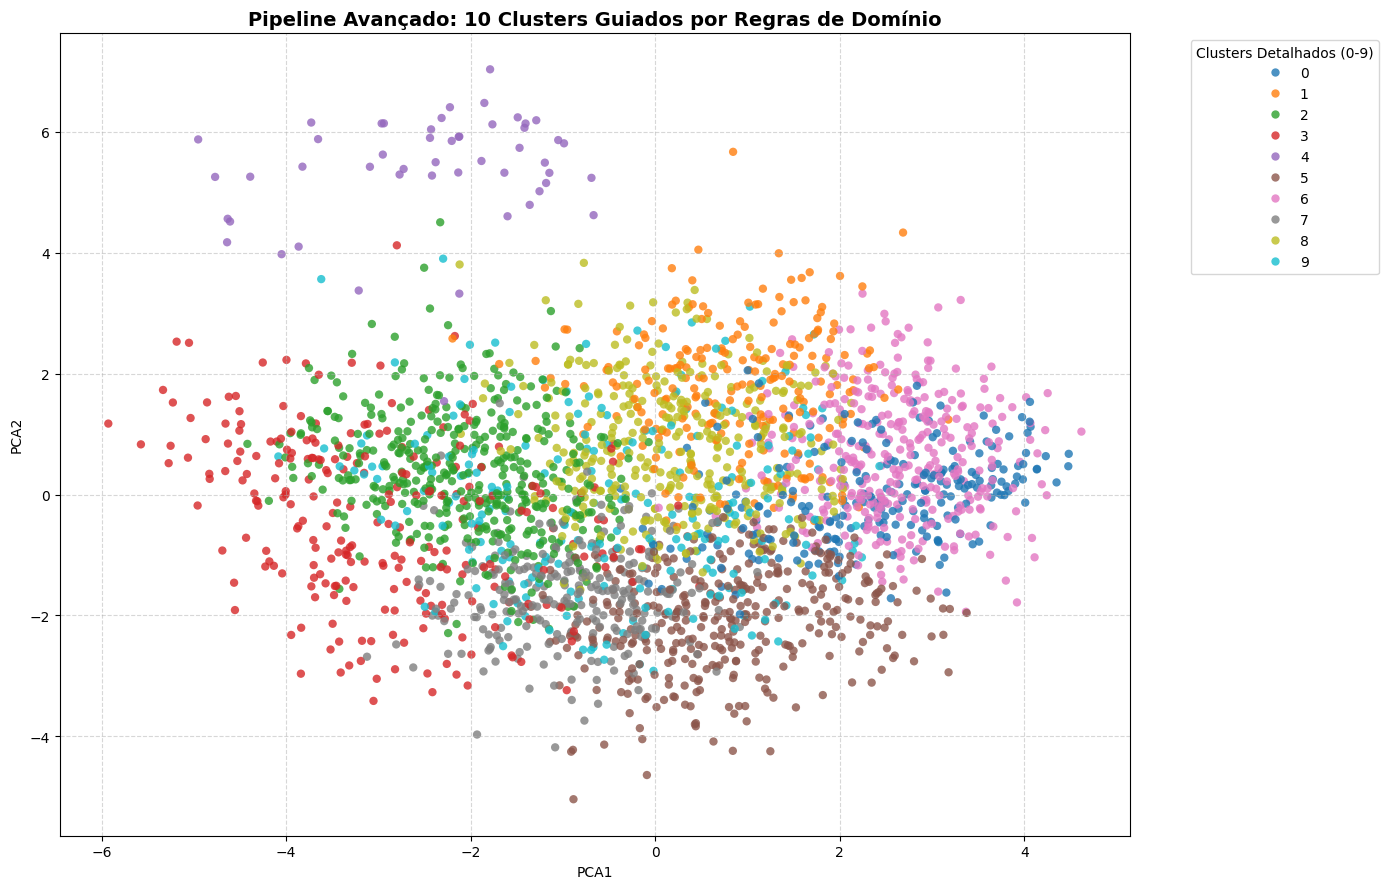


=== DISTRIBUIÇÃO DOS PROJETOS (10 CLUSTERS) ===
cluster_10
0    231
1    238
2    409
3    247
4     50
5    363
6    349
7    255
8    346
9    217
Name: count, dtype: int64


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# 1. Trazer o dicionário de labels estruturado (usando as categorias fornecidas)
regras_tematicas = {
    "COMPUTACAO_DADOS": [
        "inteligência artificial", "inteligencia artificial", "machine learning", "aprendizado de máquina", 
        "deep learning", "redes neurais", "visão computacional", "nlp", "ocr", "análise de dados", "big data"
    ],
    "ENERGIA": [
        "energia solar", "energia elétrica", "eficiência energética", "lítio", "conversores"
    ],
    "RESIDUOS_MEIO_AMBIENTE": [
        "resíduo", "resíduos", "reciclagem", "efluentes", "carbono", "tratamento de água"
    ],
    "SAUDE_BIOTECNOLOGIA": [
        "paciente", "pacientes", "clínico", "hospitalar", "médico", "médica", "dispositivo médico", "diagnóstico", "fármaco"
    ],
    "ALIMENTOS_AGRO": [
        "alimentos", "agricultura", "agrícola", "agroindústria", "cultivo", "soja", "milho", "cana-de-açúcar", "pragas"
    ],
    "ENGENHARIA_MATERIAIS": [
        "manufatura aditiva", "fabricação", "propriedades mecânicas", "ligas metálicas", "aço", "compósitos", "metalurgia"
    ]
}

# 2. Criar a Matriz de Frequência de Domínio (Contagem de palavras-chave no texto original)
print("Construindo matriz de features baseada em regras de domínio...")
matriz_regras = np.zeros((len(df_clean), len(regras_tematicas)))

for idx, texto in enumerate(df_clean['texto_completo'].str.lower()):
    for col_idx, (area, termos) in enumerate(regras_tematicas.items()):
        score = sum(texto.count(termo) for termo in termos)
        matriz_regras[idx, col_idx] = score

# Normalizar os scores para que valores muito altos não dominem o BERT
matriz_regras_norm = matriz_regras / (matriz_regras.max(axis=0) + 1e-5)

# 3. Concatenar TUDO: BERTimbau (768) + TF-IDF (100) + Regras de Domínio (6)
# Isso cria a sua Super-Matriz Híbrida de 874 colunas
X_super_hibrido = np.hstack([embeddings_bert, matriz_tfidf, matriz_regras_norm])
print(f"Nova matriz construída com formato: {X_super_hibrido.shape}")

# 4. Rodar o KMeans com K=10 para separar os blocos amontoados
K_FINAL = 10
print(f"\nTreinando o KMeans Guiado com K={K_FINAL} clusters...")
kmeans_guiado = KMeans(n_clusters=K_FINAL, random_state=42, n_init=15)
df_clean['cluster_10'] = kmeans_guiado.fit_predict(X_super_hibrido)

# 5. Visualização Gráfica Avançada com PCA
pca_10 = PCA(n_components=2, random_state=42)
coords_2d = pca_10.fit_transform(X_super_hibrido)
df_clean['PCA1'] = coords_2d[:, 0]
df_clean['PCA2'] = coords_2d[:, 1]

plt.figure(figsize=(14, 9))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='cluster_10',
    palette='tab10', # Paleta ideal para 10 cores separadas
    data=df_clean,
    alpha=0.8,
    edgecolor='none'
)
plt.title(f'Pipeline Avançado: 10 Clusters Guiados por Regras de Domínio', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Clusters Detalhados (0-9)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n=== DISTRIBUIÇÃO DOS PROJETOS (10 CLUSTERS) ===")
print(df_clean['cluster_10'].value_counts().sort_index())

### 7. Extração de Termos-Chave e Identificação Temática dos Clusters

Este bloco implementa a etapa de interpretação e rotulagem pós-modelagem, mapeando quais vocábulos carregam o maior peso descritivo dentro de cada uma das 10 novas partições:

1. **Filtragem de Termos Abstratos (Stopwords Customizadas):** Instancia um dicionário de exclusão contendo jargões metodológicos comuns (como *"desenvolvimento"*, *"projeto"*, *"processo"*). Isso remove o ruído comum de domínio científico, permitindo que apenas termos técnicos específicos apareçam.
2. **Modelagem local por N-Gramas:** Configura um extrator TF-IDF focado individualmente em cada cluster, capturando tanto palavras isoladas quanto termos compostos de até dois elementos (`ngram_range=(1, 2)`), como *"inteligência artificial"*.
3. **Ponderação por Relevância:** Soma a pontuação estatística de cada termo dentro do subconjunto e ordena os resultados de forma decrescente (`argsort()[::-1]`). O script exibe as 8 palavras fundamentais dominantes por grupo, fornecendo a base lógica para nomear as 10 vertentes de inovação do dataset.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Reutilizar nossa lista de exclusão de termos genéricos
stopwords_customizadas = {
    'desenvolvimento', 'desenvolver', 'projeto', 'processo', 'produto', 
    'produção', 'objetivo', 'visar', 'ser', 'utilizar', 'aplicação', 'uso',
    'sistema', 'tecnologia', 'modelo', 'solução', 'pesquisa', 'estudo', 'criar',
    'implementar', 'melhorar', 'analisar', 'eficiente', 'forma', 'base', 'meio'
}

# Configurar o extrator para os 10 grupos
tfidf_10 = TfidfVectorizer(
    max_features=20, 
    stop_words=list(stopwords_customizadas),
    ngram_range=(1, 2)
)

print("=== IDENTIDADE DOS 10 CLUSTERS GUIADOS ===\n")

for i in range(10):
    textos_do_cluster = df_clean[df_clean['cluster_10'] == i]['texto_lemmatized']
    
    # Evita quebra se o cluster estiver vazio por algum motivo
    if len(textos_do_cluster) > 0:
        matriz_temp = tfidf_10.fit_transform(textos_do_cluster)
        pesos_termos = np.asarray(matriz_temp.sum(axis=0)).ravel()
        nomes_termos = np.array(tfidf_10.get_feature_names_out())
        
        indices_ordenados = pesos_termos.argsort()[::-1][:8] # Top 8 palavras marcantes
        termos_chave = nomes_termos[indices_ordenados]
        
        print(f"🔹 CLUSTER {i} ({len(textos_do_cluster)} projetos)")
        print(f"👉 Termos-chave: {', '.join(termos_chave)}")
        print("-" * 50)

=== IDENTIDADE DOS 10 CLUSTERS GUIADOS ===

🔹 CLUSTER 0 (231 projetos)
👉 Termos-chave: software, plataforma, dispositivo, embarcar, inteligente, dado, equipamento, monitoramento
--------------------------------------------------
🔹 CLUSTER 1 (238 projetos)
👉 Termos-chave: inteligente, gestão, plataforma, dado, empresa, informação, inteligência, artificial
--------------------------------------------------
🔹 CLUSTER 2 (409 projetos)
👉 Termos-chave: material, alto, aço, propriedade, rota, indústria, avaliar, se
--------------------------------------------------
🔹 CLUSTER 3 (247 projetos)
👉 Termos-chave: controle, cultura, planta, agrícola, praga, solo, produtividade, soja
--------------------------------------------------
🔹 CLUSTER 4 (50 projetos)
👉 Termos-chave: es, ncia, vel, produc, dado, rio, me, de
--------------------------------------------------
🔹 CLUSTER 5 (363 projetos)
👉 Termos-chave: equipamento, material, controle, protótipo, dispositivo, inspeção, componente, monitoramento
-

### 8. Rotulagem Definitiva, Amostragem de Validação e Exportação de Resultados

Este bloco final conclui o pipeline, convertendo os agrupamentos matemáticos em classificações inteligíveis para o negócio e gerando a entrega final:

1. **Mapeamento de Negócio (*Label Assignment*):** Converte os índices numéricos ($0$ a $9$) criados pelo K-Means em rótulos textuais formais (ex: *"HealthTech & Equipamentos Médicos"*), consolidando a coluna `area_tecnologica_final`.
2. **Amostragem Aleatória de Auditoria:** Seleciona e exibe uma amostra aleatória fixa (`random_state=10`) de 10 projetos cruzando seus títulos com as novas categorias atribuídas pelo modelo, servindo como uma etapa rápida de validação e controle de qualidade visual.
3. **Persistência de Dados (Exportação):** Salva o DataFrame higienizado, vetorizado e categorizado em um arquivo estruturado `resultado_clusterizacao_transformers.csv` com codificação `utf-8`. Este artefato serve como base pronta para a geração de dashboards, relatórios estatísticos e apresentações executivas do grupo.

In [9]:
# 1. Definir o dicionário com os 10 novos nomes de clusters mapeados
mapa_10_clusters = {
    0: "Sistemas Embarcados & Hardware",
    1: "Inteligência Artificial & Analytics",
    2: "Engenharia de Materiais & Metalurgia",
    3: "Agrotecnologia & Ciências Agrárias",
    4: "Outliers (Ruídos de Codificação)",
    5: "Automação & Inspeção Industrial",
    6: "IoT & Redes de Comunicação",
    7: "Sustentabilidade & Biomassa",
    8: "Eletromobilidade & Energia",
    9: "HealthTech & Equipamentos Médicos"
}

# 2. Aplicar o mapeamento no DataFrame
df_clean['area_tecnologica_final'] = df_clean['cluster_10'].map(mapa_10_clusters)

# 3. Exibir uma amostra real cruzando o Título com a Nova Área Detectada
print("=== VERIFICAÇÃO DE ASSERÇÃO DO MODELO ===")
pd.set_option('display.max_colwidth', 100)
print(df_clean[['Título_Público', 'area_tecnologica_final']].sample(10, random_state=10))

# 4. Salvar o DataFrame final em um arquivo CSV para o seu grupo usar em relatórios
df_clean.to_csv('resultado_clusterizacao_transformers.csv', index=False, encoding='utf-8')
print("\nArquivo 'resultado_clusterizacao_transformers.csv' salvo com sucesso no diretório de trabalho do Kaggle!")

=== VERIFICAÇÃO DE ASSERÇÃO DO MODELO ===
                                                                                           Título_Público  \
1990  Desenvolvimento de Tecnologias de Informática Abrangendo Atividades de Pesquisa e Desenvolviment...   
1059                                                                         Aplicação de IA na Logística   
675                                                                            MDI  Dados de Capnografia   
593                                                              Desenvolvimento de envasadores metálicos   
1114                                                                                      Controlador PID   
2483                                                         Visão Computacional para Inspeção de Cerdas.   
1760                                                                     Solução de Conectividade LoRaWAN   
2148                                                                     Tinta UV - No